In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import galsim
import torch
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision.utils import save_image
import wandb

from claude_model_NIR import EuclidJWSTSuperResolution
from train_claude_NIR import AstronomicalDataset
from claude_model_NIR_2 import EuclidToJWSTSuperResolution, EuclidToJWSTDataset

In [8]:
MODEL_PATH = "best_sweep_model_tbra2akh.pth"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---- Load dataset ----
euclid_data = "../data/euclid_NIR_cosmos_41px_Y.npy"
jwst_data = "../data/jwst_cosmos_205px_F115W.npy"

dataset = EuclidToJWSTDataset(euclid_data, jwst_data)
torch.manual_seed(42)
val_size = int(0.2 * len(dataset))
train_size = len(dataset) - val_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=4)

# ---- Load model ----
checkpoint = torch.load('best_sweep_model_tbra2akh.pth', map_location=DEVICE)
model = EuclidToJWSTSuperResolution(num_rrdb=8, features=64)
model.load_state_dict(checkpoint)
model.to(DEVICE)
model.eval()

# print(f"Model loaded from epoch {checkpoint['epoch']}")
# print(f"Best validation loss: {checkpoint['best_val_loss']:.6f}")

EuclidToJWSTSuperResolution(
  (conv_first): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (rrdb_blocks): ModuleList(
    (0-7): 8 x ResidualDenseBlock(
      (conv1): Conv2d(64, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (conv2): Conv2d(96, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (conv3): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (conv4): Conv2d(160, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (conv5): Conv2d(192, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (lrelu): LeakyReLU(negative_slope=0.2, inplace=True)
    )
  )
  (trunk_conv): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (detail_enhancer): DetailEnhancementModule(
    (edge_conv): Sequential(
      (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): LeakyReLU(negative_slope=0.2, inplace=True)
      (2): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1))

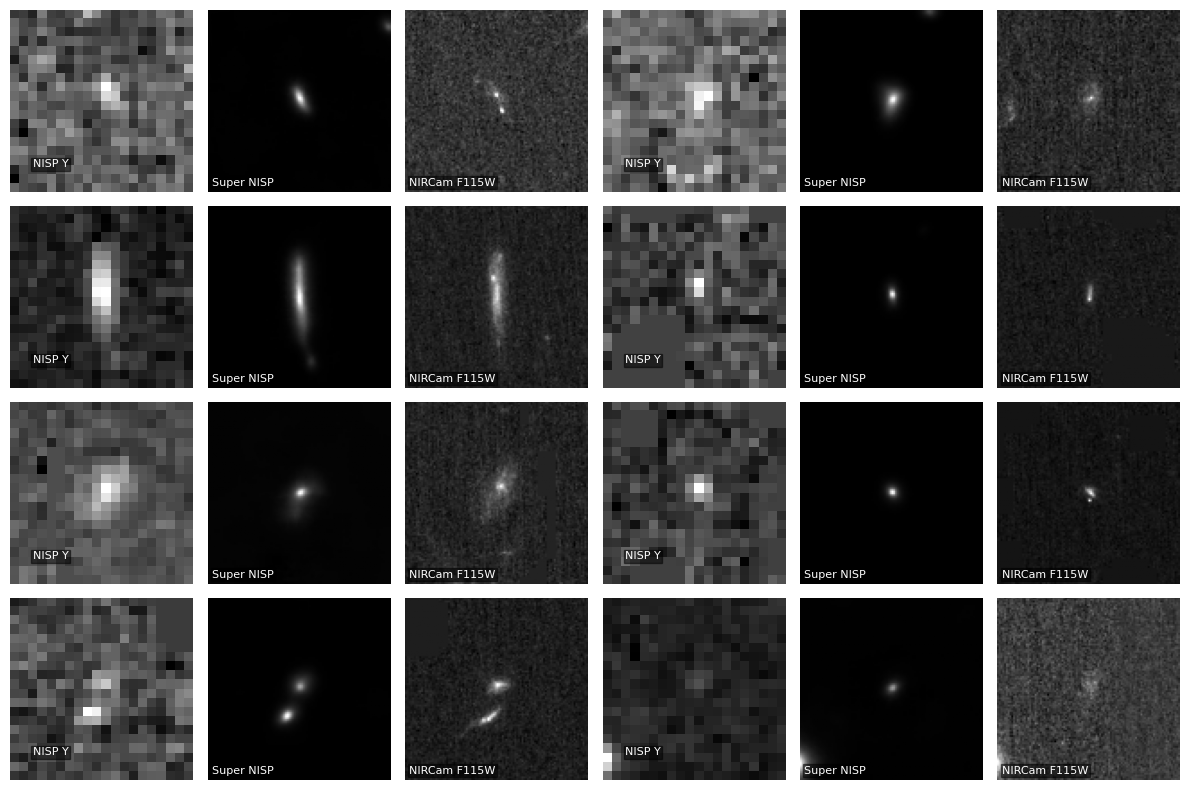

In [24]:
def center_crop(img2d, frac=0.6):
    """
    Crop the central fraction of a 2D numpy array.
    frac=0.6 keeps the central 60% of each dimension.
    """
    h, w = img2d.shape
    ch, cw = int(frac * h), int(frac * w)
    start_h = (h - ch) // 2
    start_w = (w - cw) // 2
    return img2d[start_h:start_h+ch, start_w:start_w+cw]

num_examples = 8
rows, cols = 4, 2  # 4 rows × 2 columns of triplets
fig, axs = plt.subplots(rows, cols * 3, figsize=(12, 8))
if rows == 1:
    axs = axs.reshape(1, -1)

def _show(ax, img2d, title):
    ax.imshow(img2d, origin="lower", cmap="gray")
    ax.axis("off")
    ax.text(2, 2, title, color="white", fontsize=8, ha="left", va="bottom",
            bbox=dict(facecolor="black", alpha=0.5, pad=1))

rng = np.random.default_rng(42)
indices = rng.choice(len(val_dataset), size=num_examples, replace=False)

for i, ds_idx in enumerate(indices):
    # Dataset returns (lr, hr, meta_dict)
    lr_img, hr_img, _ = val_dataset[ds_idx]   # lr: [1,41,41], hr: [1,205,205]

    # Batch input
    lr_batch = lr_img.unsqueeze(0).to(DEVICE)       # [1,1,41,41]

    with torch.no_grad():
        out = model(lr_batch)                       # forward(self, x)
    # Handle models that return a tensor or a tuple/dict
    if isinstance(out, (tuple, list)):
        sr_img = out[0]
    elif isinstance(out, dict):
        # try common keys
        sr_img = out.get("sr", None) or out.get("pred", None) or out.get("output", None)
        if sr_img is None:
            raise ValueError(f"Model returned dict with keys {list(out.keys())}, but no SR tensor found.")
    else:
        sr_img = out
    sr_img = sr_img.detach().cpu().squeeze(0)       # -> [1,205,205]

    
    lr_np = center_crop(lr_img[0].cpu().numpy(), frac=0.5)   # try 0.7 for LR
    sr_np = center_crop(sr_img[0].numpy(), frac=0.5)
    hr_np = center_crop(hr_img[0].cpu().numpy(), frac=0.5)


    row = i // cols
    base = (i % cols) * 3
    _show(axs[row, base + 0], lr_np, "NISP Y")
    _show(axs[row, base + 1], sr_np, "Super NISP")
    _show(axs[row, base + 2], hr_np, "NIRCam F115W")

plt.tight_layout()
plt.show()

In [28]:
print(np.shape(lr_img[0]))
print(np.shape(hr_img[0]))
print(len(val_dataset))

torch.Size([41, 41])
torch.Size([205, 205])
10645


In [ ]:
import numpy as np
import torch
import galsim

# --- results ---
e1_lr, e2_lr, g1_lr, g2_lr = [], [], [], []
e1_hr, e2_hr, g1_hr, g2_hr = [], [], [], []
e1_sr, e2_sr, g1_sr, g2_sr = [], [], [], []

# Optional: center crop before measuring (helps S/N on central galaxy)
def center_crop(img2d, frac=0.8):
    h, w = img2d.shape
    ch, cw = int(frac*h), int(frac*w)
    sh, sw = (h-ch)//2, (w-cw)//2
    return img2d[sh:sh+ch, sw:sw+cw]

def get_moments(image_np, pixel_scale=0.1, crop_frac=None, bkg_subtract=True):
    """
    Returns [e1, e2, g1, g2] using GalSim HSM adaptive moments.
    - image_np: 2D array
    - pixel_scale: arcsec/pixel (or your working units)
    - crop_frac: if given (e.g., 0.8), measure on center crop
    - bkg_subtract: subtract median background before moments
    """
    try:
        arr = np.asarray(image_np, dtype=np.float32)
        if crop_frac is not None:
            arr = center_crop(arr, frac=crop_frac)
        if bkg_subtract:
            arr = arr - np.nanmedian(arr)
        # Replace NaNs/Infs that can trip HSM
        arr = np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0)

        # GalSim expects (ncol, nrow)
        img = galsim.ImageF(arr.shape[1], arr.shape[0], scale=pixel_scale)
        img.array[:, :] = arr   # assign into the view to preserve dtype/stride

        res = galsim.hsm.FindAdaptiveMom(img)
        return [res.observed_e1, res.observed_e2, res.observed_shape.g1, res.observed_shape.g2]
    except Exception:
        return [np.nan, np.nan, np.nan, np.nan]

# --- loop over validation set ---
model.to(DEVICE).eval()

N = min(2000, len(val_dataset))
for i in range(N):
    # dataset returns (lr, hr, meta)
    lr_img, hr_img, _ = val_dataset[i]          # lr: [1,41,41], hr: [1,205,205]

    # SR inference
    with torch.no_grad():
        lr_batch = lr_img.unsqueeze(0).to(DEVICE)      # [1,1,Hlr,Wlr]
        out = model(lr_batch)                           # forward(self, x)
        sr_img = out[0] if isinstance(out, (tuple, list)) else (out["sr"] if isinstance(out, dict) and "sr" in out else out)
        sr_img = sr_img.detach().cpu().squeeze(0)      # -> [1,Hsr,Wsr]

    # to numpy 2D
    lr_np = lr_img[0].cpu().numpy()
    hr_np = hr_img[0].cpu().numpy()
    sr_np = sr_img[0].numpy()

    # (optional) use a consistent crop for all three to focus on the galaxy core
    crop_frac = 0.8   # tweak 0.6–0.9 as you like
    lr_vals = get_moments(lr_np, pixel_scale=0.10, crop_frac=crop_frac)
    hr_vals = get_moments(hr_np, pixel_scale=0.06, crop_frac=crop_frac)
    sr_vals = get_moments(sr_np, pixel_scale=0.06, crop_frac=crop_frac)

    e1_lr.append(lr_vals[0]); e2_lr.append(lr_vals[1]); g1_lr.append(lr_vals[2]); g2_lr.append(lr_vals[3])
    e1_hr.append(hr_vals[0]); e2_hr.append(hr_vals[1]); g1_hr.append(hr_vals[2]); g2_hr.append(hr_vals[3])
    e1_sr.append(sr_vals[0]); e2_sr.append(sr_vals[1]); g1_sr.append(sr_vals[2]); g2_sr.append(sr_vals[3])


In [ ]:
# Plot e1 and e2 comparisons
fig, axs = plt.subplots(1, 3, figsize=(15, 4))

axs[0].scatter(e1_lr, e1_hr, s=10, alpha=0.9, label='NISP')
axs[0].scatter(e1_sr, e1_hr, s=10, alpha=0.4, label='SuperNISP')
axs[0].plot([-1, 1], [-1, 1], 'k--')
axs[0].set_xlabel("e1")
axs[0].set_ylabel("e1 (NIRCam)")
axs[0].legend()

axs[1].scatter(e2_lr, e2_hr, s=10, alpha=0.9, label='NISP')
axs[1].scatter(e2_sr, e2_hr, s=10, alpha=0.4, label='SuperNISP')
axs[1].plot([-1, 1], [-1, 1], 'k--')
axs[1].set_xlabel("e2 ")
axs[1].set_ylabel("e2 (NIRCam)")
axs[1].legend()

axs[2].scatter(e1_sr, e1_hr, s=10, alpha=0.9, label='e1')
axs[2].scatter(e2_sr, e2_hr, s=10, alpha=0.5, label='e2')
axs[2].plot([-1, 1], [-1, 1], 'k--')
axs[2].set_xlabel("e NIRCam")
axs[2].set_ylabel("e superNISP")
axs[2].legend()

plt.tight_layout()
plt.show()


In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(12, 4))

axs[0].scatter(g1_lr, g1_hr, s=10, alpha=0.9, label='NISP')
axs[0].scatter(g1_sr, g1_hr, s=10, alpha=0.4, label='SuperNISP')
axs[0].plot([-1, 1], [-1, 1], 'k--')
axs[0].set_xlabel("g1")
axs[0].set_ylabel("g1 (NIRCam)")
axs[0].legend()

axs[1].scatter(g2_lr, g2_hr, s=10, alpha=0.9, label='NISP')
axs[1].scatter(g2_sr, g2_hr, s=10, alpha=0.4, label='SuperNISP')
axs[1].plot([-1, 1], [-1, 1], 'k--')
axs[1].set_xlabel("g2 ")
axs[1].set_ylabel("g2 (NIRCam)")
axs[1].legend()

axs[2].scatter(g1_hr, g1_sr, s=10, alpha=0.9, label='g1')
axs[2].scatter(g2_hr, g2_sr, s=10, alpha=0.4, label='g2')
axs[2].plot([-1, 1], [-1, 1], 'k--')
axs[2].set_xlabel("g NIRCam ")
axs[2].set_ylabel("g super NISP")
axs[2].legend()

plt.tight_layout()
plt.show()


In [ ]:

fig, axs = plt.subplots(1, 2, figsize=(10, 4))

# Histogram for g1
axs[0].hist(g1_lr, bins=30, alpha=0.9, label='NISP',histtype='step')
axs[0].hist(g1_sr, bins=30, alpha=0.9, label='SuperNISP',histtype='step')
axs[0].hist(g1_hr, bins=30, alpha=0.9, label='NIRCam',histtype='step')
axs[0].set_xlabel("g1")
axs[0].set_ylabel("Density")
axs[0].legend()

# Histogram for g2
axs[1].hist(g2_lr, bins=30, alpha=0.9, label='NISP',histtype='step')
axs[1].hist(g2_sr, bins=30, alpha=0.9, label='SuperNISP',histtype='step')
axs[1].hist(g2_hr, bins=30, alpha=0.9, label='NIRCam',histtype='step')
axs[1].set_xlabel("g2")
axs[1].set_ylabel("Density")
axs[1].legend()
axs[1].set_xlim([-0.4,0.4])
axs[0].set_xlim([-0.4,0.4])

plt.tight_layout()
plt.show()


In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

# Histogram for g1
axs[0].hist(e1_lr, bins=50, alpha=0.9, label='NISP',histtype='step',density=True)
axs[0].hist(e1_sr, bins=50, alpha=0.9, label='SuperNISP',histtype='step',density=True)
axs[0].hist(e1_hr, bins=50, alpha=0.9, label='NIRCam',histtype='step',density=True)
axs[0].set_xlabel("e1")
axs[0].legend()

# Histogram for g2
axs[1].hist(e2_lr, bins=50, alpha=0.9, label='NISP',histtype='step',density=True)
axs[1].hist(e2_sr, bins=50, alpha=0.9, label='SuperNISP',histtype='step',density=True)
axs[1].hist(e2_hr, bins=50, alpha=0.9, label='NIRCam',histtype='step',density=True)
axs[1].set_xlabel("e2")
axs[1].legend()
axs[1].set_xlim([-0.3,0.3])
axs[0].set_xlim([-0.3,0.3])
plt.tight_layout()
plt.show()
